# Hematopoiesis case study: transcriptomic analyses

This notebook explores the STREAM representation used to define the hematopoietic macrostates and their Boolean abstractions. It consumes the compact exports generated by `scripts/build_notebook_data.py`.

### Table of contents

1. [Data overview](#data)
2. [Spectral trajectory](#spectral)
3. [Macrostate composition](#composition)
4. [STREAM trajectory](#stream)
5. [Macrostate binarisation](#binarisation)

### Figure index <a class="anchor" id="figure-index"></a>

| Notebook section | Generated file |
| --- | --- |
| [Spectral trajectory](#spectral) | `se_macrostates.pdf` |
| [Macrostate composition](#composition) | `cell_proportions.pdf` |
| [STREAM trajectory](#stream) | `streamplot.pdf` |


### Notebook setup


In [46]:
import warnings
from pathlib import Path

import bonesistools as bt
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
from matplotlib import transforms
from tqdm import TqdmWarning

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"IProgress not found.*",
        category=TqdmWarning,
    )
    warnings.filterwarnings(
        "ignore",
        message=r"pandas\.core\.index is deprecated.*",
        category=FutureWarning,
        module=r"rpy2\.robjects\.pandas2ri",
    )
    import stream as st

bt.omics.pl.set_default_params()


def find_hematopoiesis_dir(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        candidates = (path, path / "hematopoiesis")
        for candidate in candidates:
            if (candidate / "scripts" / "build_notebook_data.py").is_file():
                return candidate
    raise FileNotFoundError(f"Could not locate hematopoiesis from {start}")


HEMATOPOIESIS_DIR = find_hematopoiesis_dir()
RESULTS_DIR = HEMATOPOIESIS_DIR / "results"
FIGURE_DIR = HEMATOPOIESIS_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

## Data overview <a class="anchor" id="data"></a>

### Load transcriptomic data

The exported STREAM object contains the spectral embedding, the inferred trajectory graph, the biological cell labels, and the six macrostates used in the Boolean specification.


In [47]:
adata = st.read(
    file_name=str(RESULTS_DIR / "omics" / "stream.pkl"),
    workdir=str(FIGURE_DIR),
)

Saving results in: /home/roncalli/Documents/these/scbolt-case-studies/hematopoiesis/figures


In [48]:
adata.uns["label_color"] = {
    "HSC": bt.omics.pl.get_color("black"),
    "MPP": bt.omics.pl.get_color("gray"),
    "LMPP": bt.omics.pl.get_color("teal"),
    "CMP": bt.omics.pl.get_color("orange"),
    "MEP": bt.omics.pl.get_color("darkred"),
    "GMP": bt.omics.pl.get_color("gold"),
}
label_order = ["HSC", "MPP", "LMPP", "CMP", "MEP", "GMP"]

macro_order = sorted(adata.obs["macrostate"].cat.categories)
palette = bt.omics.pl.get_palette("classic").colors
macro_color = dict(zip(macro_order, palette[: len(macro_order)]))

## Spectral trajectory <a class="anchor" id="spectral"></a>

The three-dimensional spectral embedding is coloured by macrostate and overlaid with the STREAM trajectory graph.


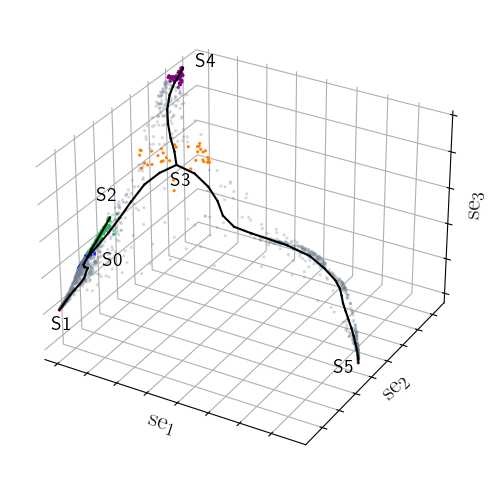

In [49]:
embedding_label = "se"
fig, ax = bt.omics.pl.trajectory(
    adata,
    obs="macrostate",
    colors=macro_color,
    representation="X_se",
    xlabel=rf"$\mathrm{{{embedding_label}_{{1}}}}$",
    ylabel=rf"$\mathrm{{{embedding_label}_{{2}}}}$",
    zlabel=rf"$\mathrm{{{embedding_label}_{{3}}}}$",
    figwidth=6,
    fontsize=14,
    s=5,
    alpha=(1.0, 0.3),
    legend=False,
    labels={"fontsize": 14, "fontweight": "extra bold"},
    graph={"linewidth": 1.5, "zorder": 10},
    n_components=3,
    background_visible=False,
    tick_params={
        "which": "both",
        "bottom": False,
        "top": False,
        "left": False,
        "right": False,
        "labelbottom": False,
        "labelleft": False,
    },
)
ax.xaxis.labelpad = -10
ax.yaxis.labelpad = -10
ax.zaxis.labelpad = -10
ax.set_xlabel(ax.get_xlabel(), fontsize=18)
ax.set_ylabel(ax.get_ylabel(), fontsize=18)
ax.set_zlabel(ax.get_zlabel(), fontsize=18)

for txt in ax.texts:
    x, y = txt.get_position()
    label = txt.get_text()
    if label == "S0":
        txt.set_position((x + 0.0015, y - 0.001))
    elif label == "S1":
        txt.set_position((x + 0.001, y - 0.003))
    elif label == "S2":
        txt.set_position((x - 0.0015, y + 0.001))
    elif label == "S3":
        txt.set_position((x + 0.0012, y - 0.0035))
    elif label == "S4":
        txt.set_position((x + 0.0008, y))
    elif label == "S5":
        txt.set_position((x - 0.0005, y - 0.0023))

fig.tight_layout()

xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, 0.0118)
ymin, ymax = ax.get_ylim()
ax.set_ylim(-0.007, ymax)
zmin, zmax = ax.get_zlim()
ax.set_zlim(zmin, 0.015)

plt.savefig(
    FIGURE_DIR / "se_macrostates.pdf", dpi=300, bbox_inches="tight", pad_inches=-0.2
)

plt.show()

## Macrostate composition <a class="anchor" id="composition"></a>

Cell-type proportions describe the biological composition of each inferred macrostate.


,n,%
HSC,375,22.6
MPP,234,14.1
LMPP,246,14.9
CMP,325,19.6
MEP,356,21.5
GMP,120,7.2


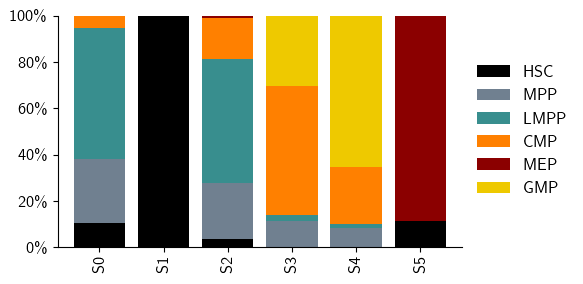

In [50]:
population_counts = adata.obs["label"].value_counts().reindex(label_order, fill_value=0)
population_composition = pd.DataFrame(
    {
        "n": population_counts,
        "%": 100 * population_counts / population_counts.sum(),
    }
)
display(population_composition.round({"%": 1}))

macro_order = ["S0", "S1", "S2", "S3", "S4", "S5"]

df = adata.obs[["macrostate", "label"]].dropna()

counts = pd.crosstab(df["macrostate"], df["label"])
counts = counts.reindex(index=macro_order, columns=label_order, fill_value=0)

props = counts.div(counts.sum(axis=1), axis=0)

ax = props.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 3),
    width=0.8,
    color=[adata.uns["label_color"][label] for label in label_order],
)

ax.set_xlabel("")
for ticklabel in ax.get_xticklabels():
    ticklabel.set_color("black")
    ticklabel.set_fontweight("bold")

ax.legend(bbox_to_anchor=(1.0, 0.85), loc="upper left", frameon=False, fontsize=12)
ax.tick_params(axis="both", labelsize=12)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.savefig(
    FIGURE_DIR / "cell_proportions.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()

## STREAM trajectory <a class="anchor" id="stream"></a>

The flat-tree STREAM view is rooted in `S1`, the initial macrostate used by the dynamical specification.


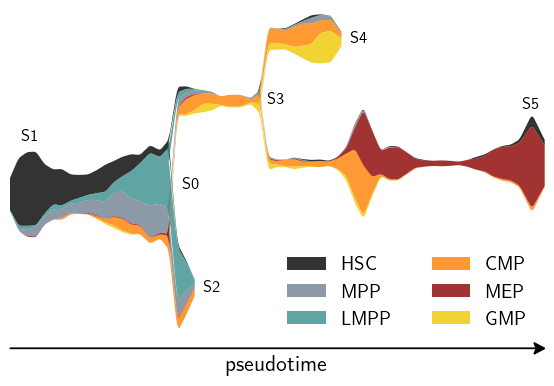

In [51]:
root = "S1"

st.plot_stream(
    adata,
    root=root,
    color=["label"],
    log_scale=False,
    factor_zoomin=100,
    save_fig=False,
    fig_legend_order={"label": label_order},
)

plt.title("")
plt.xticks([])

ax = plt.gca()

legend = ax.get_legend()
handles = legend.legendHandles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()
ax.legend(
    handles,
    labels,
    loc="lower right",
    bbox_to_anchor=(1.0, 0.05),
    ncol=2,
    fontsize=14,
    frameon=False,
)

dy = +0.15
arrow = ax.get_children()[6]
arrow.set_transform(
    arrow.get_transform()
    + transforms.ScaledTranslation(0, dy, ax.figure.dpi_scale_trans)
)

ax.xaxis.set_label_coords(0.5, 0.02)
ax.xaxis.label.set_fontsize(16)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0)
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 0.85)

state_label_positions = {
    "S1": (0.000500, 0.002420),
    "S0": (0.029818, -0.004420),
    "S2": (0.030544, -0.017680),
    "S3": (0.043837, 0.007640),
    "S4": (0.054811, 0.017680),
    "S5": (0.088899, 0.007000),
}
# Adjust these (x, y) offsets, in points, to fine-tune individual labels.
state_label_offsets = {
    "S1": (12, 7),
    "S0": (0, 7),
    "S2": (12, 0),
    "S3": (0, 7),
    "S4": (12, 0),
    "S5": (-12, 7),
}

for state, position in state_label_positions.items():
    ax.annotate(
        state,
        xy=position,
        xytext=state_label_offsets[state],
        textcoords="offset points",
        ha="center",
        va="center",
        color="black",
        fontsize=12,
        fontweight="bold",
        annotation_clip=False,
    )

plt.savefig(
    FIGURE_DIR / "streamplot.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Macrostate binarisation <a class="anchor" id="binarisation"></a>

Each macrostate is represented as a partially defined Boolean vector over genes. Values `0`, `1`, and missing respectively denote inactive, active, and undefined components.


In [52]:
mstates_df = pd.read_csv(RESULTS_DIR / "spec" / "mstates.csv", index_col=0)
pct_bin = mstates_df.notna().sum(axis=1) / mstates_df.shape[1]
display(mstates_df)

,Depp1,Phf6,Usp14,Zfp358,Rag2,Hmgcs1,Gm36948,Atad2,Mns1,Tbc1d5,...,Slc27a6,Iigp1c,Rab18,Mzb1,Cxxc5,B4galt6,Rnf125,Rnf138,Taf4b,Zfp521
macrostate,,,,,,,,,,,,,,,,,,,,,
S0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,1.0
S1,NaN,0.0,NaN,1.0,NaN,NaN,NaN,0.0,0.0,0.0,...,1.0,1.0,NaN,0.0,NaN,NaN,1.0,0.0,NaN,NaN
S2,1.0,1.0,1.0,NaN,1.0,0.0,NaN,1.0,NaN,1.0,...,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
S3,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S4,NaN,1.0,1.0,NaN,0.0,0.0,1.0,1.0,1.0,NaN,...,NaN,NaN,1.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0
S5,NaN,NaN,1.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN
